In [1]:
%matplotlib inline  

import matplotlib as mpl  # 기본 설정 만지는 용도
import matplotlib.pyplot as plt  # 그래프 그리는 용도
import matplotlib.font_manager as fm  # 폰트 관련 용도
import os
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore')
#plt.rc('font', family='NanumBarunGothic') 

from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [2]:
data19 = pd.read_csv('./data19.csv')
data20 = pd.read_csv('./data20.csv')
data21 = pd.read_csv('./data21.csv')

In [12]:
data19

,HID,PID,smartphone_ary19,studyneg_ary19,studypos_ary19,lifesatis_ary19,happy_ary19,selfpos_ary19,angry_ary19,dump_ary19,group_ary19,grit_ary19,distraction_ary19,timewithparent_ary19,parentlove_ary19,parentorder_ary19,relaiton_class_ary19,parentincome_ary19,bully_ary19,vio19
0,780,2,2.200,2.444,3.000,2.0,2.25,2.556,3.0,2.857,4.000,2.500,2.4,11.0,3.000,2.8,1,4.0,1.0,1
1,1192,2,2.800,2.333,3.143,2.6,3.00,3.000,2.0,1.714,3.308,3.000,2.2,7.0,3.429,2.2,1,5.0,1.0,0
2,1193,2,2.333,1.667,2.714,3.0,3.75,4.000,2.0,1.571,4.000,2.750,2.2,8.0,3.000,2.2,1,9.0,1.2,0
3,1285,2,1.800,2.000,2.000,2.0,3.25,3.111,2.0,1.857,2.538,2.625,2.4,7.0,2.857,2.0,1,5.0,1.0,1
4,1590,2,1.867,1.444,2.429,2.0,3.25,3.444,1.8,1.714,2.846,3.125,2.0,8.0,3.286,1.6,1,2.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2585,5157,1,2.400,2.111,1.571,2.4,3.00,2.889,3.0,2.571,2.385,2.375,2.4,9.0,3.000,2.6,1,7.0,1.0,1
2586,5158,1,1.400,1.222,3.143,3.4,3.75,4.000,1.6,1.000,3.615,3.375,1.4,11.0,4.000,1.2,1,8.0,1.0,0
2587,5159,1,1.867,1.667,2.857,2.6,3.00,2.889,1.8,1.571,3.077,2.625,2.0,10.0,3.000,2.0,1,5.0,1.0,0
2588,5160,1,2.200,1.000,3.286,3.6,4.00,3.556,1.6,1.000,4.000,3.000,2.4,11.0,3.143,1.0,1,6.0,1.0,0


In [13]:
data20

,HID,PID,smartphone_ary20,studyneg_ary20,studypos_ary20,lifesatis_ary20,happy_ary20,selfpos_ary20,angry_ary20,dump_ary20,group_ary20,grit_ary20,distraction_ary20,timewithparent_ary20,parentlove_ary20,parentorder_ary20,relaiton_class_ary20,parentincome_ary20,bully_ary20,vio20
0,780,2,2.267,2.000,2.571,1.8,3.00,2.778,3.4,2.143,3.000,2.500,3.2,9.0,2.857,2.6,1,4.0,1.0,0
1,1192,2,2.533,2.889,2.571,3.2,3.00,2.556,3.2,2.857,2.846,2.375,2.6,4.0,3.286,3.2,1,6.0,1.0,0
2,1193,2,2.400,2.222,2.714,3.8,2.75,3.556,2.2,2.143,3.231,2.250,2.6,12.0,3.857,2.6,1,9.0,1.0,0
3,1285,2,1.867,2.111,2.143,2.2,3.50,3.222,2.4,1.714,2.538,2.500,2.4,7.0,3.000,1.8,1,5.0,1.0,0
4,1590,2,1.267,1.778,3.286,2.8,3.25,3.444,1.2,1.286,3.154,3.000,1.4,14.0,3.429,1.2,1,2.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2585,5157,1,2.667,2.889,1.000,2.6,3.25,2.000,2.2,2.857,2.154,2.500,3.2,9.0,3.000,1.8,1,7.0,1.0,1
2586,5158,1,1.000,1.111,3.714,3.2,3.25,3.778,1.8,1.286,3.231,3.375,1.4,9.0,3.143,3.2,1,9.0,1.0,1
2587,5159,1,1.133,1.556,3.000,2.6,3.25,3.111,1.2,1.000,3.000,3.250,1.8,12.0,3.000,1.2,1,4.0,1.0,0
2588,5160,1,1.467,1.111,3.429,4.0,4.00,3.778,1.6,1.000,3.615,3.000,2.2,14.0,4.000,1.6,1,5.0,1.0,0


In [3]:
col = ['HID', 'PID', 'smartphone_addiction', 
'academic_indifference', 
'academic_enthusiasm',
'life_satisfaction',
'happiness',
'self_esteem',
'aggression',
'depressed',
'cooperation',
'grit',
'distraction',
'time_with_parents',
'parents_affection',
'parents_coercion',
'guardianship',
'family_income',
'bully',
'school_violence'
]

In [4]:
data19.columns = col
data20.columns = col
data21.columns = col

# EDA

<AxesSubplot:title={'center':'2019 Correlation of Features'}>

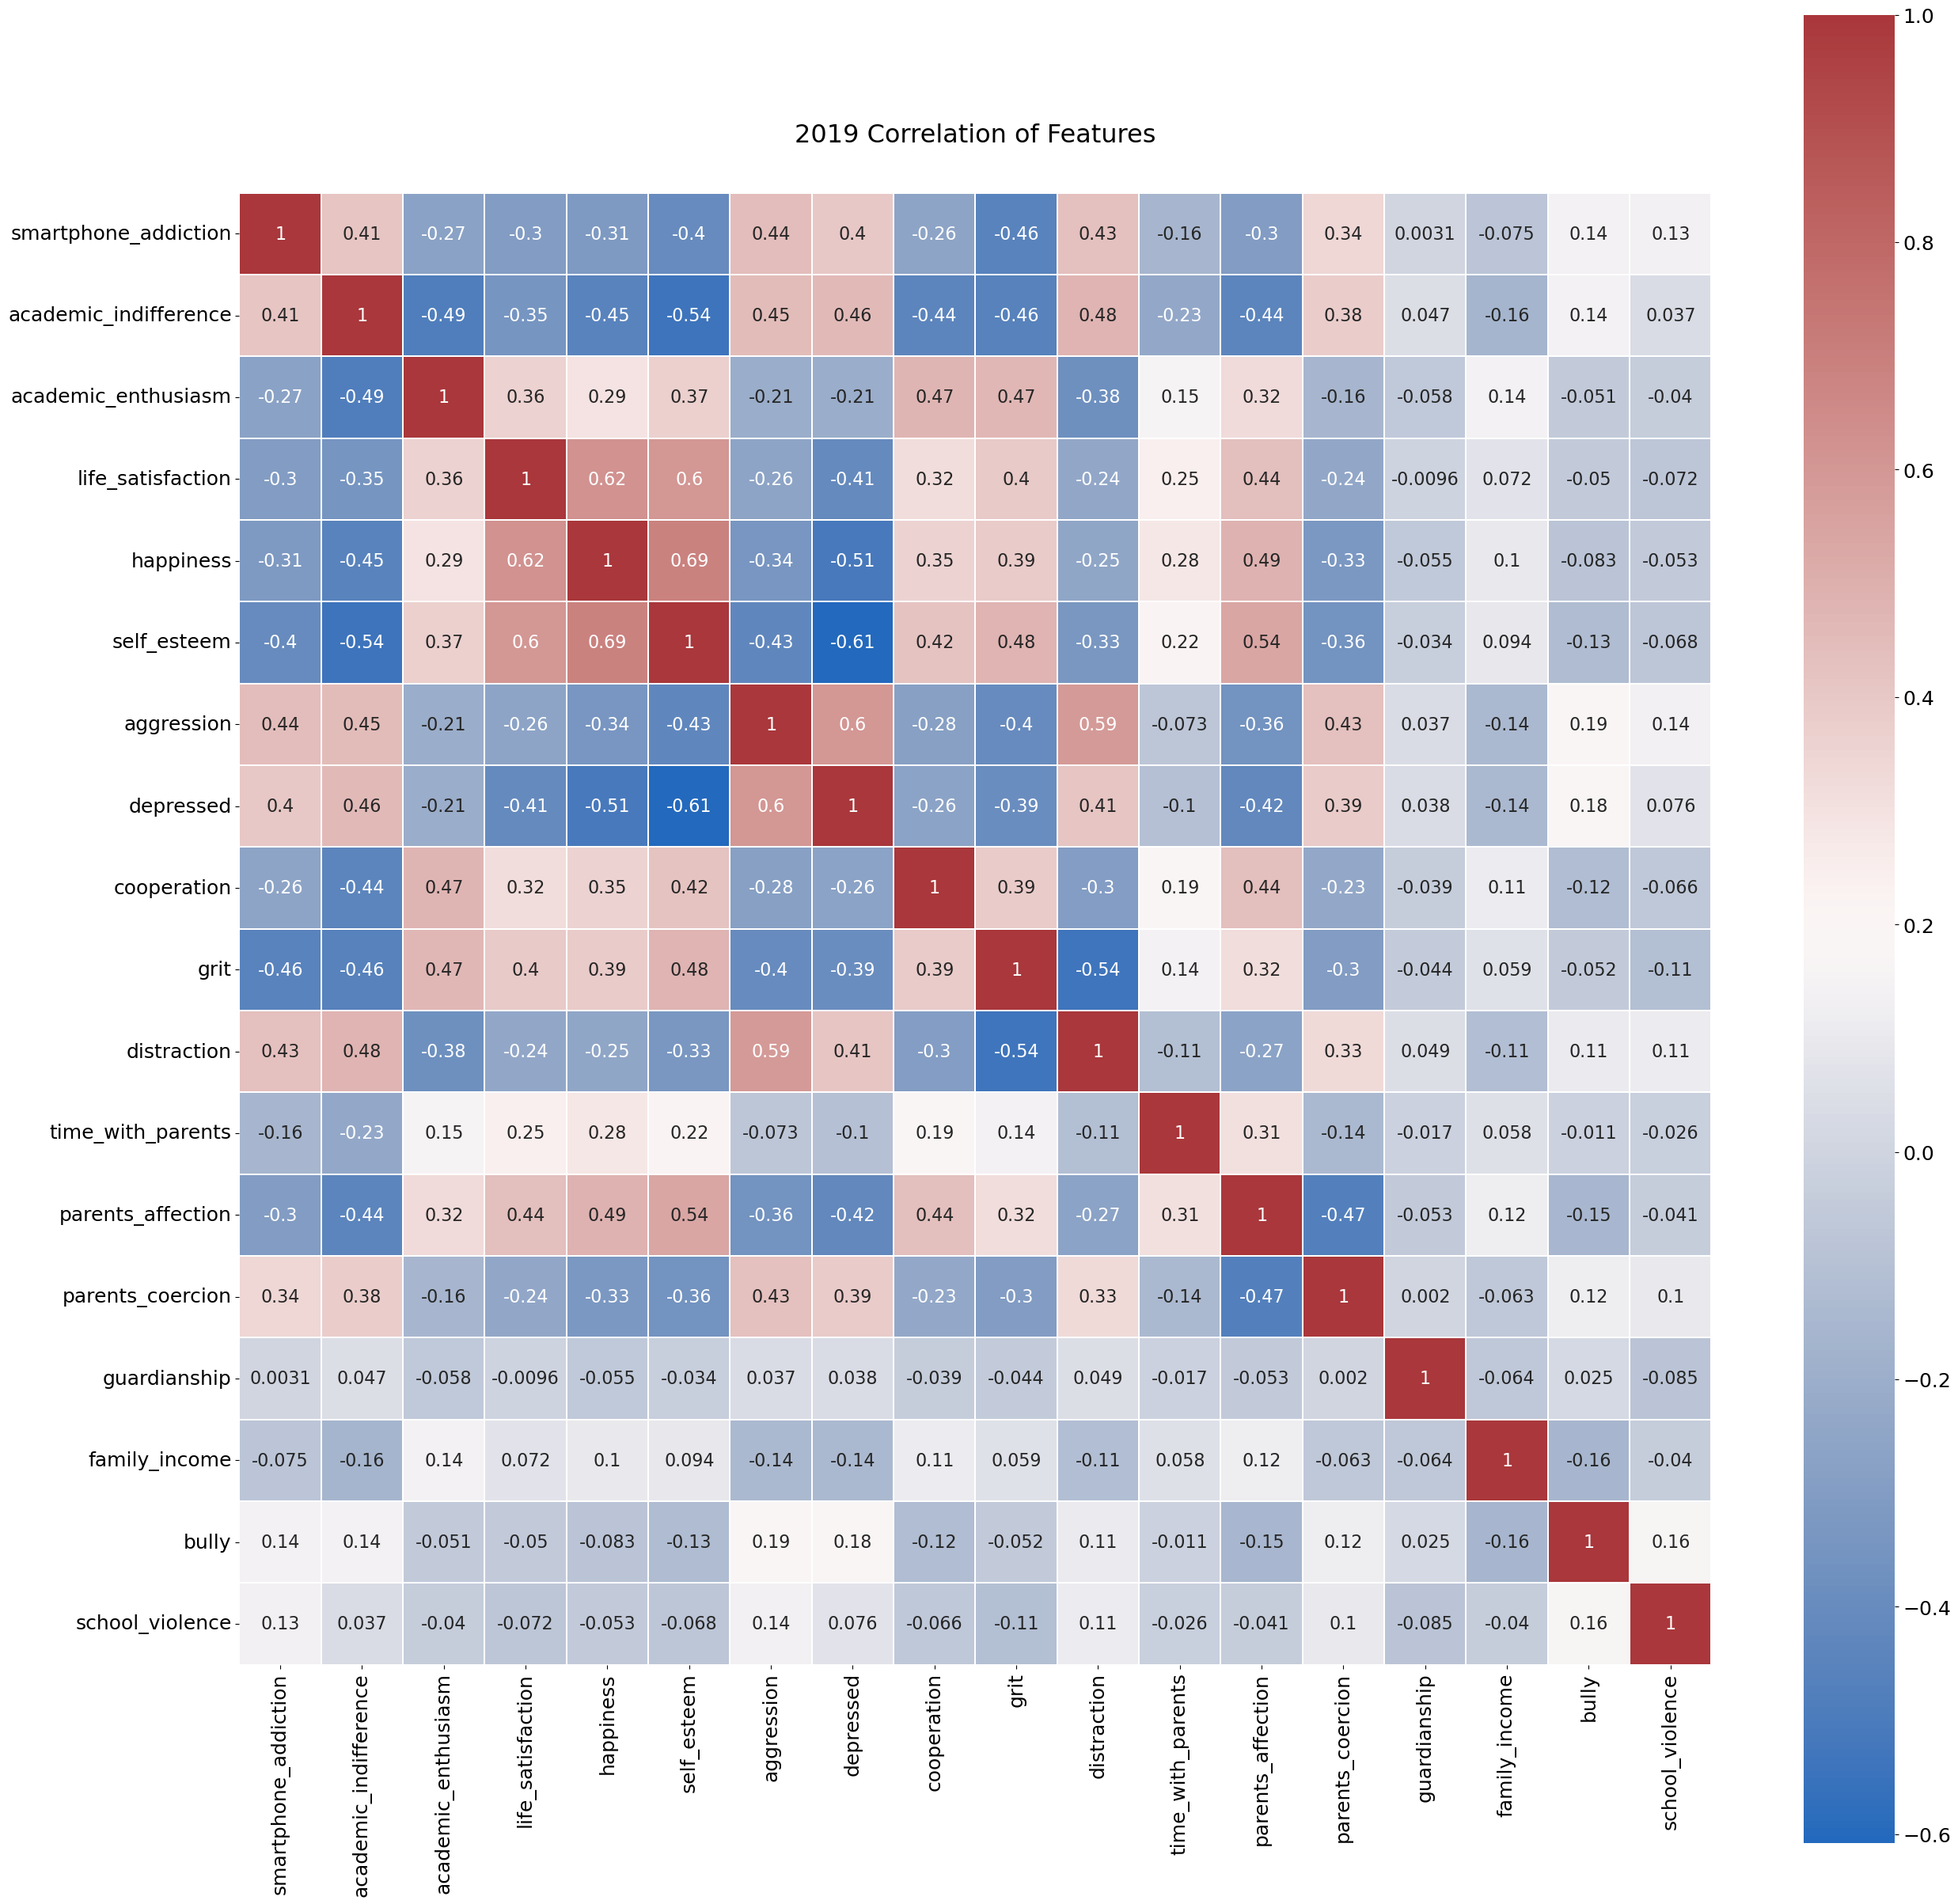

In [54]:
plt.rc('xtick', labelsize=18) 
plt.rc('ytick', labelsize=18) 
plt.figure(figsize=(30, 30))
plt.title("2019 Correlation of Features", y = 1.03, size = 23)
sns.heatmap(data19.iloc[:, 2:].astype(float).corr(), linewidths = 0.1, vmax = 1.0,
           square = True, cmap = 'vlag', linecolor = "white", annot = True, annot_kws = {"size" : 16})

<AxesSubplot:title={'center':'2020 Correlation of Features'}>

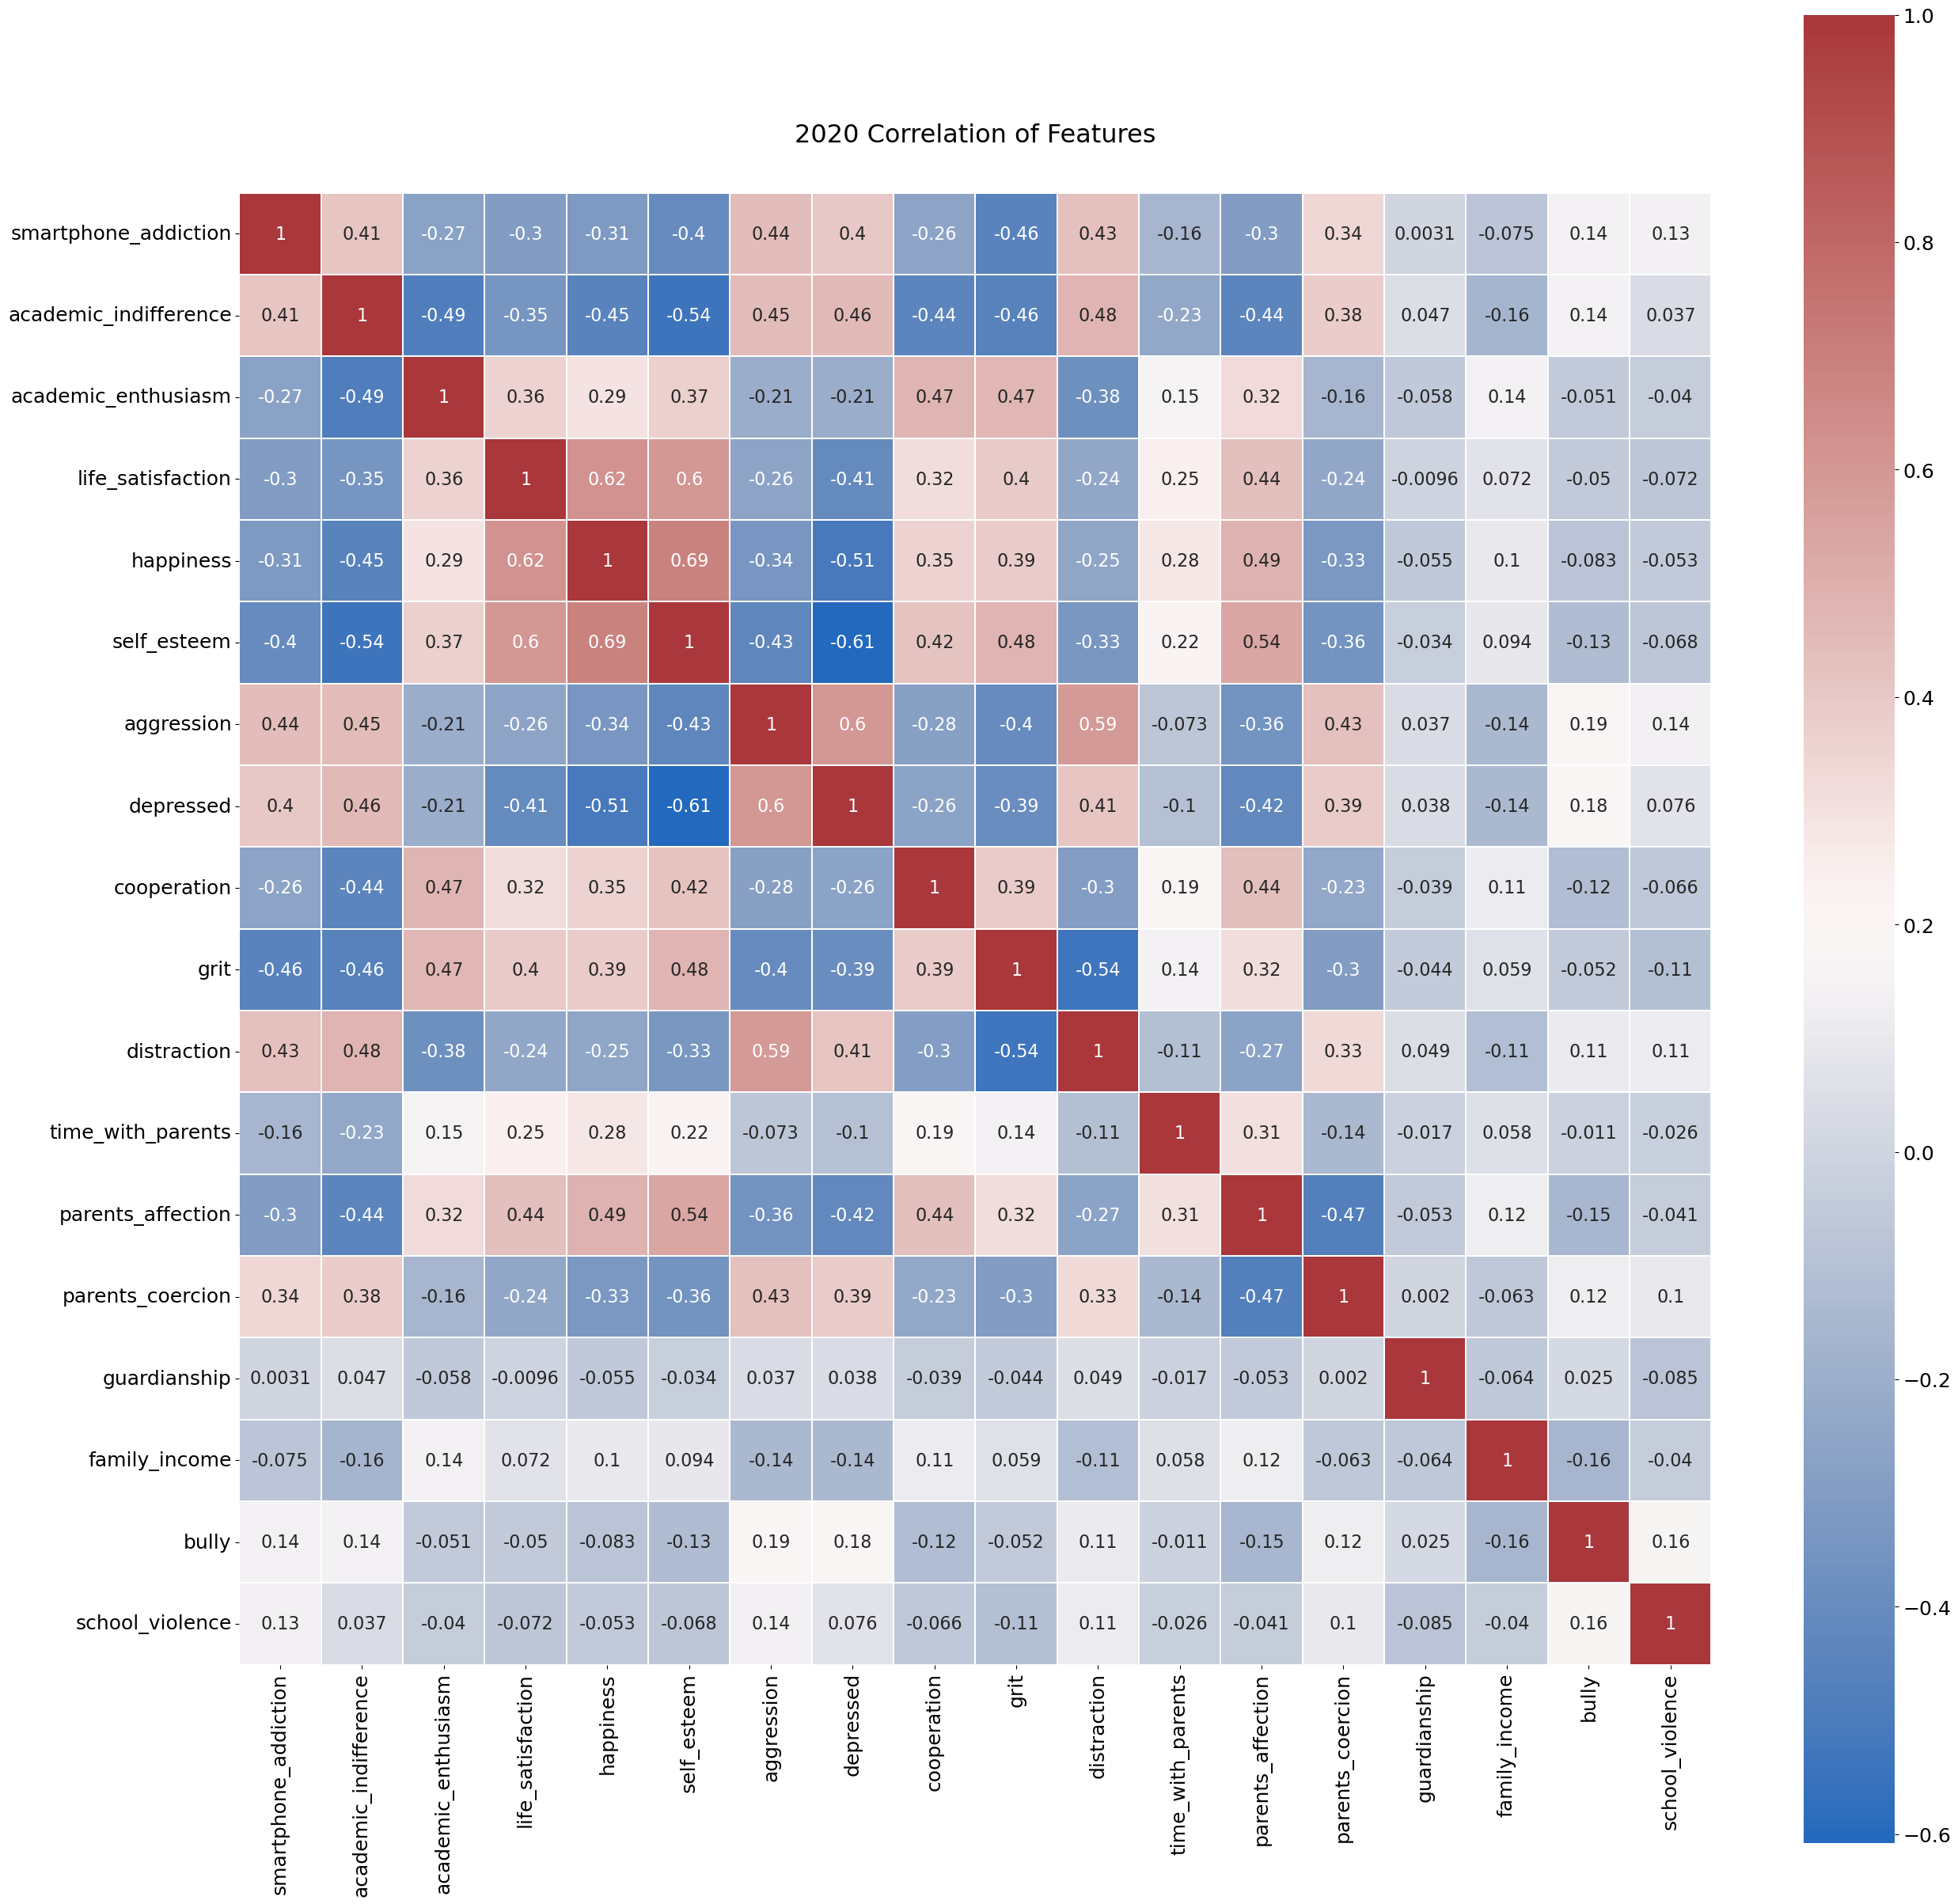

In [53]:
plt.rc('xtick', labelsize=18) 
plt.rc('ytick', labelsize=18) 
plt.figure(figsize=(30, 30))
plt.title("2020 Correlation of Features", y = 1.03, size = 23)
sns.heatmap(data19.iloc[:, 2:].astype(float).corr(), linewidths = 0.1, vmax = 1.0,
           square = True, cmap = 'vlag', linecolor = "white", annot = True, annot_kws = {"size" : 16})

<AxesSubplot:title={'center':'2021 Correlation of Features'}>

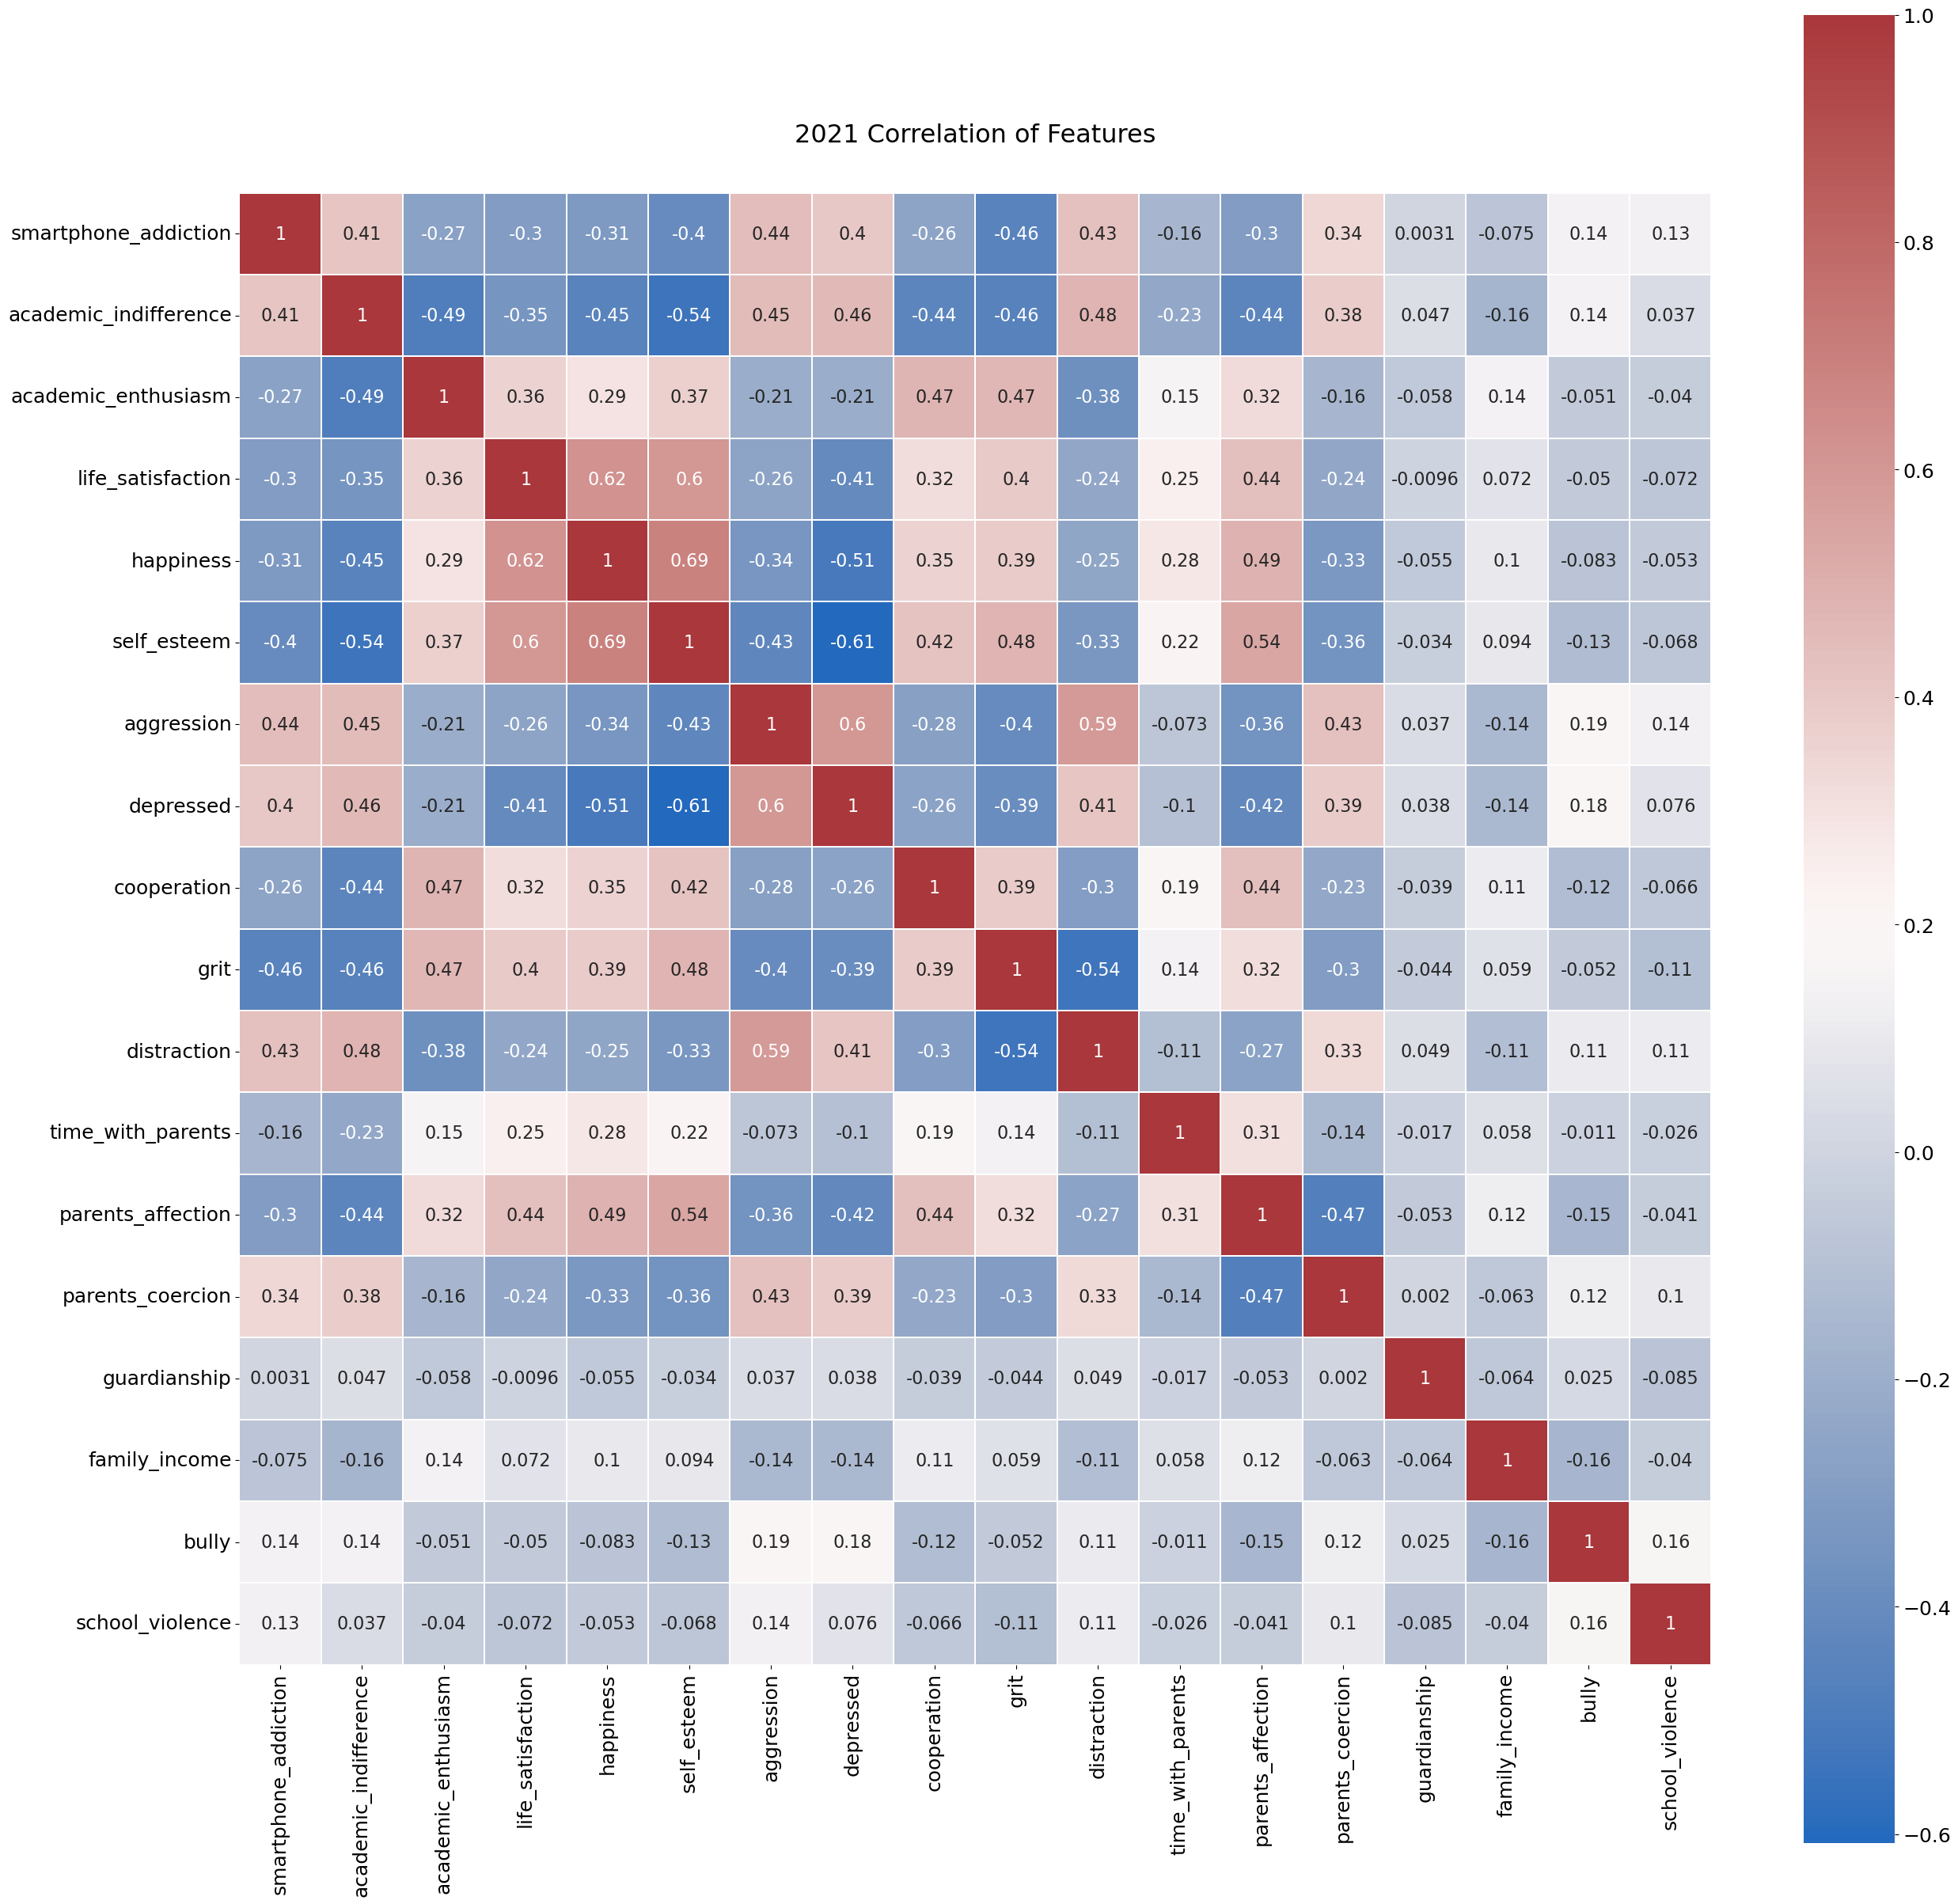

In [51]:
plt.rc('xtick', labelsize=18) 
plt.rc('ytick', labelsize=18) 
plt.figure(figsize=(30, 30))
plt.title("2021 Correlation of Features", y = 1.03, size = 23)
sns.heatmap(data19.iloc[:, 2:].astype(float).corr(), linewidths = 0.1, vmax = 1.0,
           square = True, cmap = 'vlag', linecolor = "white", annot = True, annot_kws = {"size" : 16})

In [159]:
import dataframe_image as dfi

st19 = data19.iloc[:, 2:].describe()
dfi.export(st19, './st19.png', max_cols = -1, max_rows = -1)

In [160]:
st20 = data20.iloc[:, 2:].describe()
dfi.export(st20, './st20.png', max_cols = -1, max_rows = -1)

In [162]:
st21 = data21.iloc[:, 2:].describe()
dfi.export(st21, './st21.png', max_cols = -1, max_rows = -1)

<AxesSubplot:xlabel='bully', ylabel='Density'>

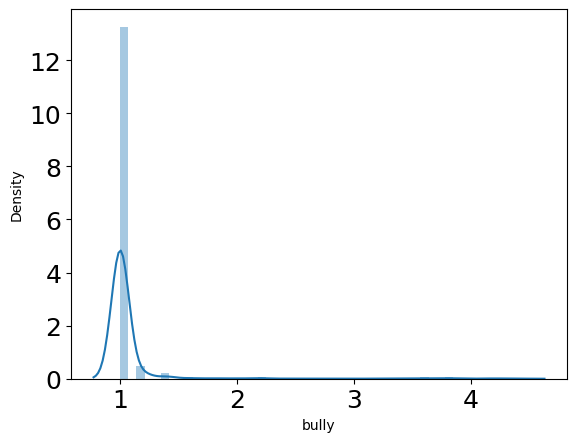

In [185]:
sns.distplot(data19.iloc[:, 18])

# 모형 학습

## 결정 트리

In [5]:
data19.dropna(inplace=True)
data20.dropna(inplace=True)
data21.dropna(inplace=True)

In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

x = data19[['smartphone_addiction', 'life_satisfaction', 'aggression', 'depressed', 'parents_coercion', 'bully']]
y = data19.iloc[:,-1] 

clf = DecisionTreeClassifier()

param_grid = {'criterion':['gini','entropy'], 
              'max_depth':[1,2,3,4,5,6], 
              'max_leaf_nodes':[1,2,3,4,5,6,7], 
              'min_samples_split':[2,3,4,5,6], 
              'min_samples_leaf':[1,2,3]}

grid = GridSearchCV(clf, param_grid=param_grid, cv=3, scoring='accuracy') #디폴트로 cv=3, 분류에서 디폴트로 scoring='accuracy'

grid.fit(x, y)

print(grid.best_score_)
print(grid.best_params_)
df = pd.DataFrame(grid.cv_results_)
print(df)


clf = grid.best_estimator_

0.8825967540574283
{'criterion': 'entropy', 'max_depth': 4, 'max_leaf_nodes': 6, 'min_samples_leaf': 1, 'min_samples_split': 2}
      mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0          0.001775      0.000339         0.000000        0.000000   
1          0.001380      0.000131         0.000000        0.000000   
2          0.001378      0.000122         0.000000        0.000000   
3          0.001301      0.000169         0.000000        0.000000   
4          0.001040      0.000026         0.000000        0.000000   
...             ...           ...              ...             ...   
1255       0.001560      0.000139         0.000740        0.000134   
1256       0.001576      0.000096         0.000578        0.000014   
1257       0.001466      0.000040         0.000636        0.000117   
1258       0.001630      0.000075         0.000626        0.000055   
1259       0.001451      0.000016         0.000554        0.000002   

     param_criterion param_max_

0.8834304746044963
smartphone_addiction 중요도 : 0.3050270835055554
life_satisfaction 중요도 : 0.0
aggression 중요도 : 0.1018749696856613
depressed 중요도 : 0.0
parents_coercion 중요도 : 0.0
bully 중요도 : 0.5930979468087832


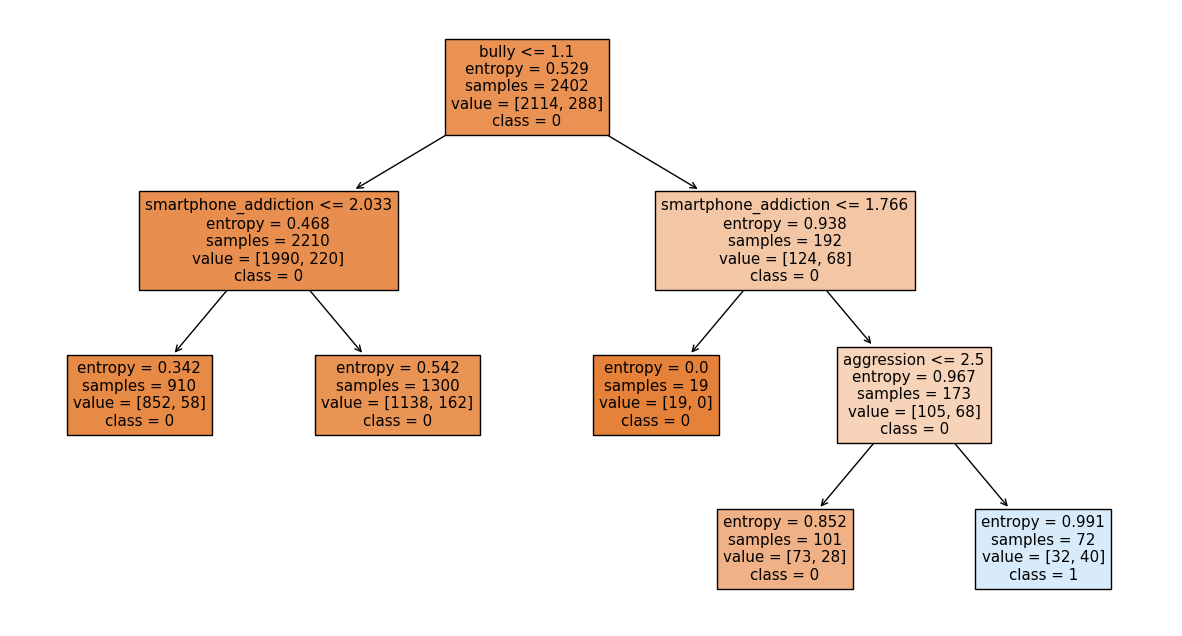

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree


# decision tree 모형 인스턴스 생성 및 하이퍼파라미터(depth) = 3
tree_model = DecisionTreeClassifier(criterion='entropy', max_depth=5, max_leaf_nodes=5, min_samples_leaf=1, min_samples_split=2, random_state=100)
tree_model.fit(x,y)
print(tree_model.score(x, y))

## 변수 중요도
for i, col in enumerate(x.columns):
    print(f'{col} 중요도 : {tree_model.feature_importances_[i]}')

fig = plt.figure(figsize=(15, 8))
_ = tree.plot_tree(tree_model, 
                  feature_names=['smartphone_addiction', 'life_satisfaction', 'aggression', 'depressed', 'parents_coercion', 'bully'],
                  class_names=['0', '1'],
                  filled=True)

In [31]:
from sklearn.metrics import *

y_pred = tree_model.predict(x)
print("confusion_matrix\n", confusion_matrix(y, y_pred))
print("accuracy_score\n",accuracy_score(y, y_pred))
print("precision_score\n",precision_score(y, y_pred))
print("recall_score\n",recall_score(y, y_pred))
print("f1_score\n",accuracy_score(y, y_pred))

confusion_matrix
 [[2082   32]
 [ 248   40]]
accuracy_score
 0.8834304746044963
precision_score
 0.5555555555555556
recall_score
 0.1388888888888889
f1_score
 0.8834304746044963


0.8968152866242038
confusion_matrix
 [[2093   31]
 [ 212   19]]
accuracy_score
 0.8968152866242038
precision_score
 0.38
recall_score
 0.08225108225108226
f1_score
 0.8968152866242038
smartphone_addiction 중요도 : 0.3050270835055554
life_satisfaction 중요도 : 0.0
aggression 중요도 : 0.1018749696856613
depressed 중요도 : 0.0
parents_coercion 중요도 : 0.0
bully 중요도 : 0.5930979468087832


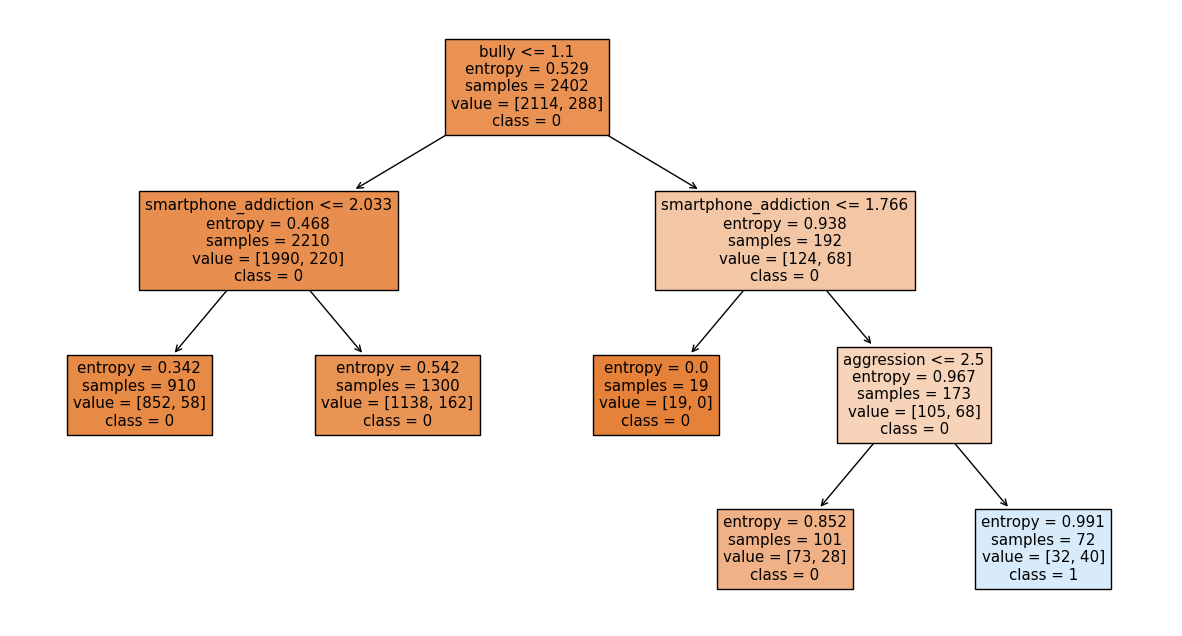

In [32]:
x20=data20[['smartphone_addiction', 'life_satisfaction', 'aggression', 'depressed', 'parents_coercion', 'bully']]
y20=data20['school_violence']
print(tree_model.score(x20, y20))

y_pred = tree_model.predict(x20)
print("confusion_matrix\n", confusion_matrix(y20, y_pred))
print("accuracy_score\n",accuracy_score(y20, y_pred))
print("precision_score\n",precision_score(y20, y_pred))
print("recall_score\n",recall_score(y20, y_pred))
print("f1_score\n",accuracy_score(y20, y_pred))

## 변수 중요도
for i, col in enumerate(x.columns):
    print(f'{col} 중요도 : {tree_model.feature_importances_[i]}')

fig = plt.figure(figsize=(15, 8))
_ = tree.plot_tree(tree_model, 
                  feature_names=['smartphone_addiction', 'life_satisfaction', 'aggression', 'depressed', 'parents_coercion', 'bully'],
                  class_names=['0', '1'],
                  filled=True)

In [33]:
x21=data21[['smartphone_addiction', 'life_satisfaction', 'aggression', 'depressed', 'parents_coercion', 'bully']]
y21=data21['school_violence']
print(tree_model.score(x21, y21))

print(tree_model.score(x21, y21))

y_pred = tree_model.predict(x21)
print("confusion_matrix\n", confusion_matrix(y21, y_pred))
print("accuracy_score\n",accuracy_score(y21, y_pred))
print("precision_score\n",precision_score(y21, y_pred))
print("recall_score\n",recall_score(y21, y_pred))
print("f1_score\n",accuracy_score(y21, y_pred))

0.9308652988403211
0.9308652988403211
confusion_matrix
 [[2080   33]
 [ 122    7]]
accuracy_score
 0.9308652988403211
precision_score
 0.175
recall_score
 0.05426356589147287
f1_score
 0.9308652988403211


# mean data

In [2]:
rf = pd.read_csv('./rf.csv')
rf

,HID,PID,smartphone_ary,angry_ary,dump_ary,group_ary,parentlove_ary,parentorder_ary,bully_ary,vio,pincome4
0,780,2,2.233500,3.200000,2.500000,3.500000,2.928500,2.700000,1.000000,1,1.000000
1,1192,2,2.666500,2.600000,2.285500,3.077000,3.357500,2.700000,1.000000,0,0.000000
2,1193,2,2.311000,2.200000,1.952333,3.410333,3.428667,2.333333,1.066667,0,0.000000
3,1285,2,1.889000,2.266667,1.619000,2.538000,2.904667,1.666667,1.000000,1,0.000000
4,1590,2,1.689000,1.800000,1.619000,3.154000,3.238333,1.600000,1.000000,0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
2497,5156,1,2.600000,2.200000,1.500000,3.038500,3.000000,2.700000,1.000000,0,0.000000
2498,5157,1,2.533500,2.600000,2.714000,2.269500,3.000000,2.200000,1.000000,1,0.000000
2499,5158,1,1.489000,1.800000,1.428667,3.359000,3.714333,1.800000,1.000000,1,0.000000
2500,5159,1,1.577667,1.466667,1.190333,3.154000,3.143000,1.733333,1.000000,1,0.666667


In [70]:
col = ['HID', 'PID', 'smartphone_addiction', 'aggression','depressed','cooperation','parents_affection','parents_coercion','bully', 'school_violence', 'income_400']

In [71]:
rf.columns = col

In [72]:
x = rf.drop(columns=['HID', 'PID', 'school_violence'])
y = rf['school_violence']
x

,smartphone_addiction,aggression,depressed,cooperation,parents_affection,parents_coercion,bully,income_400
0,2.233500,3.200000,2.500000,3.500000,2.928500,2.700000,1.000000,1.000000
1,2.666500,2.600000,2.285500,3.077000,3.357500,2.700000,1.000000,0.000000
2,2.311000,2.200000,1.952333,3.410333,3.428667,2.333333,1.066667,0.000000
3,1.889000,2.266667,1.619000,2.538000,2.904667,1.666667,1.000000,0.000000
4,1.689000,1.800000,1.619000,3.154000,3.238333,1.600000,1.000000,1.000000
...,...,...,...,...,...,...,...,...
2497,2.600000,2.200000,1.500000,3.038500,3.000000,2.700000,1.000000,0.000000
2498,2.533500,2.600000,2.714000,2.269500,3.000000,2.200000,1.000000,0.000000
2499,1.489000,1.800000,1.428667,3.359000,3.714333,1.800000,1.000000,0.000000
2500,1.577667,1.466667,1.190333,3.154000,3.143000,1.733333,1.000000,0.666667


In [83]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100, ## 붓스트랩 샘플 개수 또는 base_estimator 개수
            criterion='entropy', ## 불순도 측도
            max_depth=5, ## 개별 나무의 최대 깊이
            bootstrap=True, ## 복원 추출,  False이면 비복원 추출
            oob_score=True, ## Out-of-bag 데이터를 이용한 성능 계산
            random_state=100)
rfc.fit(x, y)

RandomForestClassifier(criterion='entropy', max_depth=5, oob_score=True,
                       random_state=100)

In [86]:
from sklearn.tree import export_graphviz
#conda install python-graphviz

estimator = rfc.estimators_[30]

export_graphviz(estimator, out_file='tree.dot', 
                feature_names = ['smartphone_ary', 'angry_ary', 'dump_ary', 'group_ary','parentlove_ary', 'parentorder_ary', 'bully_ary', 'pincome4'],
                class_names = ['0', '1'],
                precision = 3, # 소수점 표기 자릿수
                filled = True, # class별 color 채우기
                rounded=True) # 박스의 모양을 둥글게

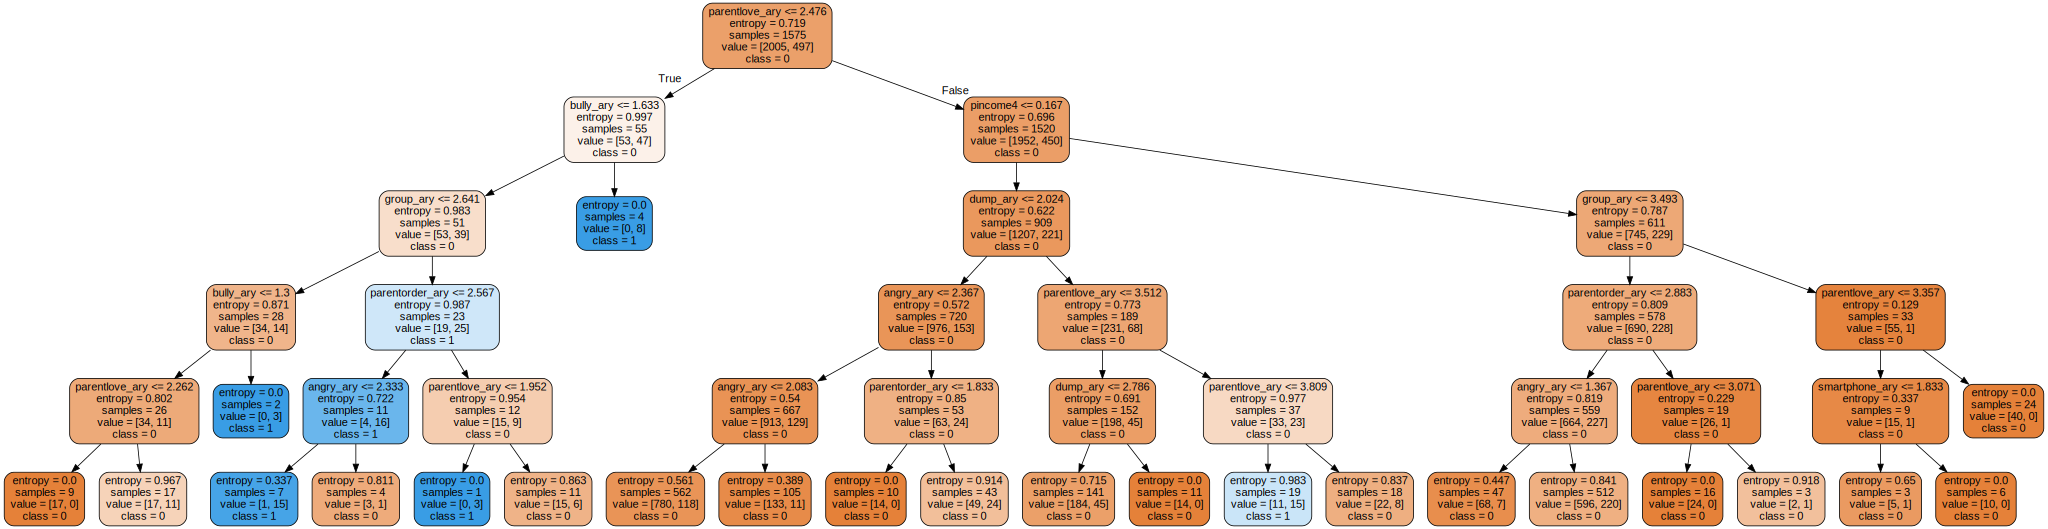

In [87]:
import graphviz

# 위에서 생성된 tree.dot 파일을 Graphviz 읽어서 Jupyter Notebook상에서 시각화 
with open("/Users/hye0n0/UOS/경제분석캡스톤디자인/code/tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

In [81]:
## 예측
print(rfc.predict(x)[:3]) 
print()
## 성능 평가
print(rfc.oob_score_) ## Out-of-bag 성능 평가 점수
print('정확도 : ', rfc.score(x,y)) ## 테스트 성능 평가 점수(Accuracy)
print()

[0 0 0]

0.7921662669864109
정확도 :  0.7969624300559552



In [82]:
## 변수 중요도
for i in range(len(x.columns)):
    print(f'{x.columns[i]}: {round(rfc.feature_importances_[i], 3)}')

smartphone_addiction: 0.1
aggression: 0.133
depressed: 0.1
cooperation: 0.08
parents_affection: 0.086
parents_coercion: 0.095
bully: 0.386
income_400: 0.02


In [ ]:
smartphone_ary: 0.1
angry_ary: 0.132
dump_ary: 0.1
group_ary: 0.096
parentlove_ary: 0.097
parentorder_ary: 0.101
bully_ary: 0.345
pincome4: 0.03

<AxesSubplot:xlabel='grit', ylabel='Density'>

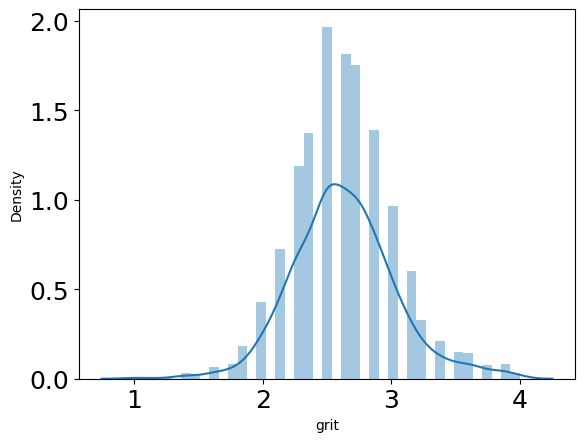

In [69]:
sns.distplot(data19['grit'])

In [58]:
len(col[2:])

18